In [1]:
import hoda
import tensorly as tl
import mne

!pip install line_profiler
%load_ext line_profiler

mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,2,0,0
1,2,0,0
2,2,0,0
3,2,0,0
4,2,0,0
...,...,...,...
4195,2,0,0
4196,2,0,0
4197,2,0,0
4198,2,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 26)

In [5]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*16,
    hoda_params=dict(
        max_iter=128,
        tol=1e-12,
        init ='mlsvd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore

%lprun -f bttda.fit bttda.fit(X,y)

Fitting block 1/16...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting block 2/16...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting block 3/16...
Fitting discriminative tensor model of rank (1, 1)...


...

Fitting block 15/16...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitting block 16/16...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/128 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 6.78463 s
File: /project/src/hoda/hoda.py
Function: fit at line 563

Line #      Hits         Time  Per Hit   % Time  Line Contents
   563                                               def fit(self, X, y=None, blocks=None):
   564         1   69010780.0    7e+07      1.0          X = tl.tensor(X)
   565         1       4490.0   4490.0      0.0          n_samples, *shape = X.shape
   566         1       1553.0   1553.0      0.0          hoda_params = self.hoda_params or dict()
   567         1       1900.0   1900.0      0.0          self.blocks_ = []
   568         1       1305.0   1305.0      0.0          self.train_info_ = []
   569                                           
   570         1   91096325.0    9e+07      1.3          err = copy(X)
   571        17      20046.0   1179.2      0.0          for b, rank in enumerate(self.ranks):
   572        16      12609.0    788.1      0.0              hoda_params["rank"] = rank
   573        16       6048.

In [16]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,mse2
0,1,"(1, 1)",0.992448,0.992448
1,2,"(1, 1)",0.977766,0.977766
2,3,"(1, 1)",0.975244,0.975244
3,4,"(1, 1)",0.974210,0.974210
4,5,"(1, 1)",0.970934,0.970934
5,6,"(1, 1)",0.966682,0.966682
6,7,"(1, 1)",0.966168,0.966168
7,8,"(1, 1)",0.959083,0.959083
8,9,"(1, 1)",0.957759,0.957759
9,10,"(1, 1)",0.949988,0.949988


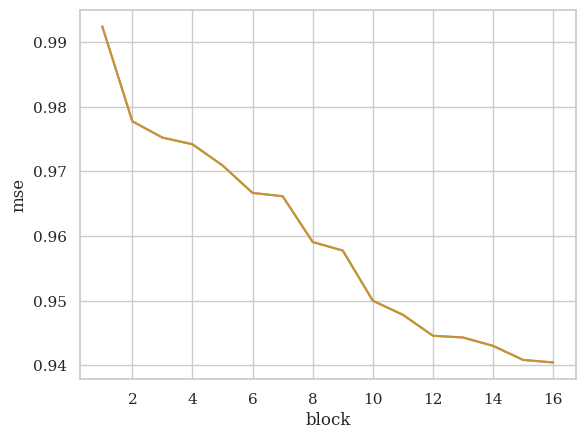

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    sns.lineplot(data=df, x='block', y='mse2')




In [18]:
Xt = bttda.transform(X)

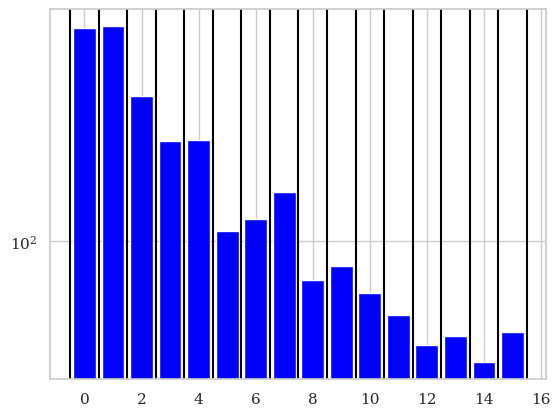

In [19]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    plt.axvline(n_params-.5, color='black')


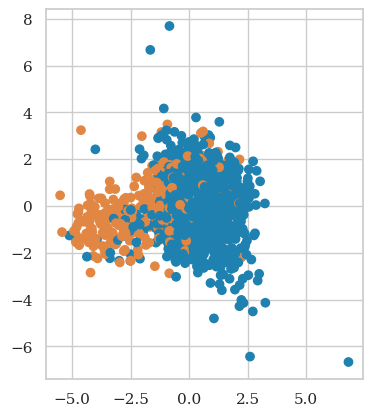

In [20]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [21]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]),units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

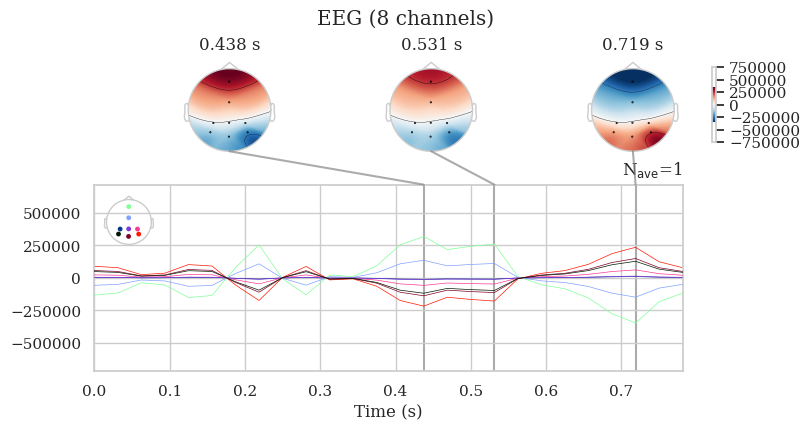

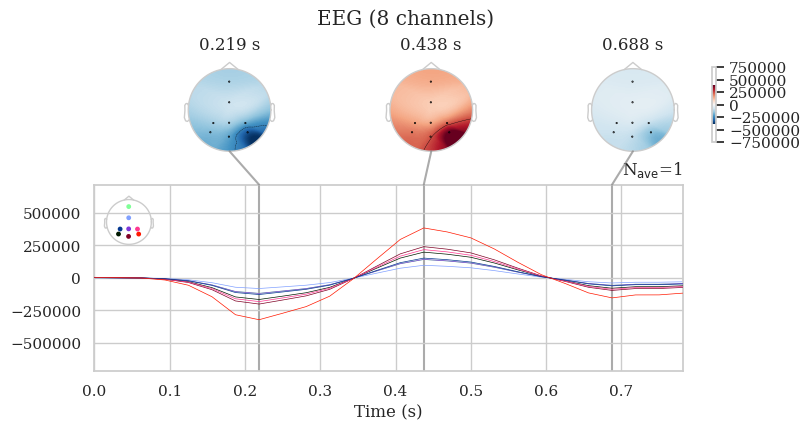

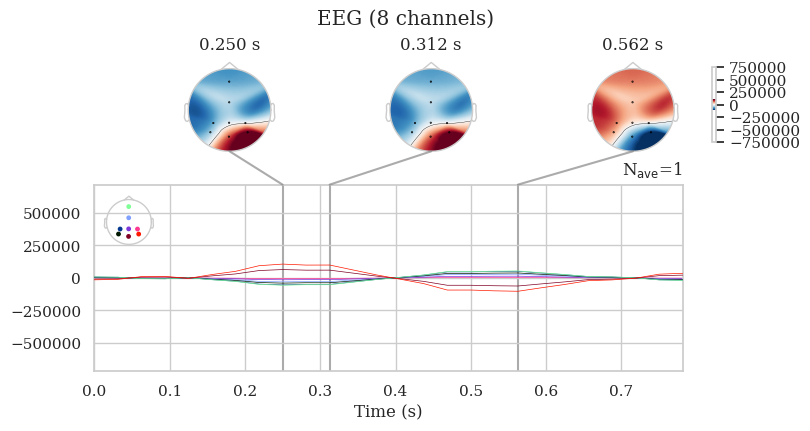

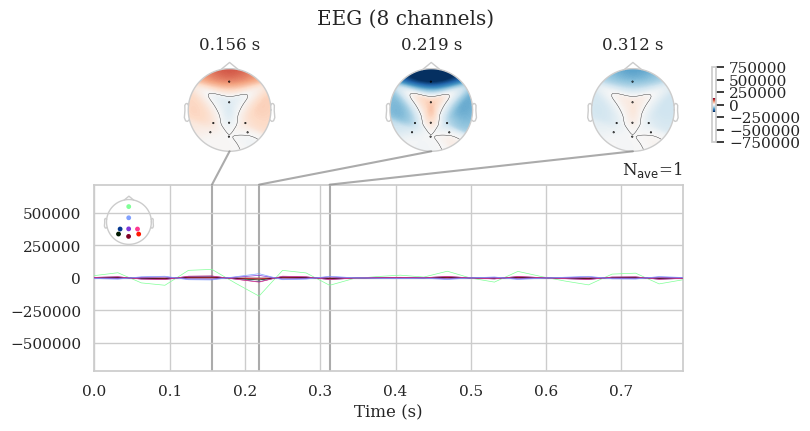

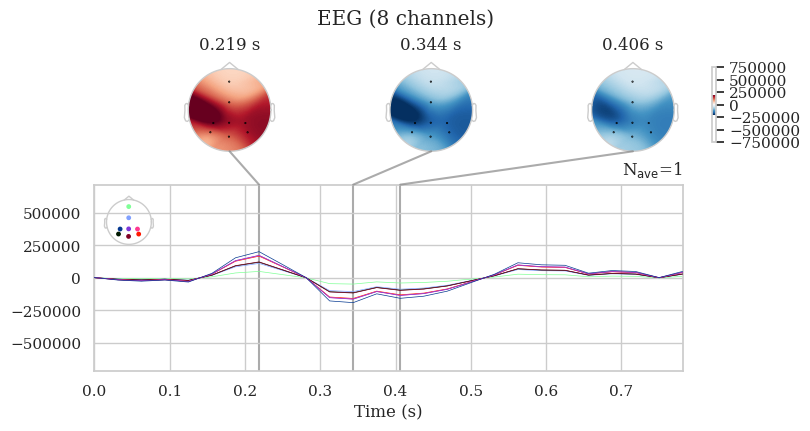

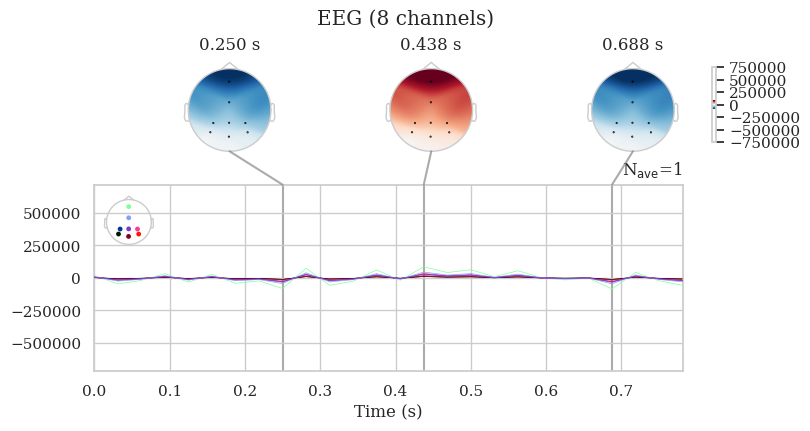

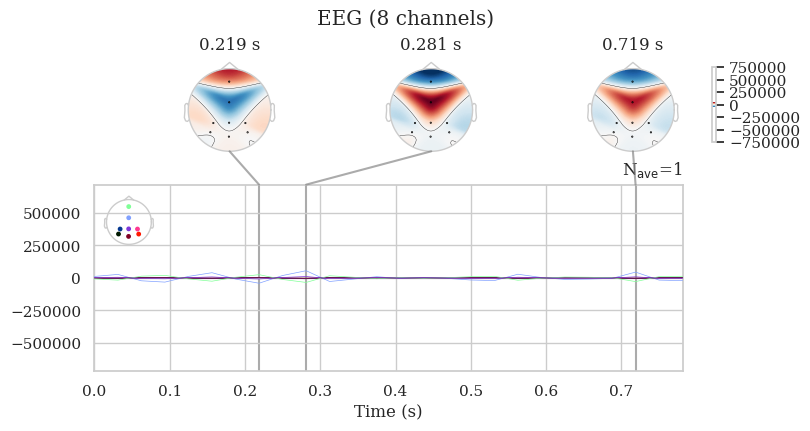

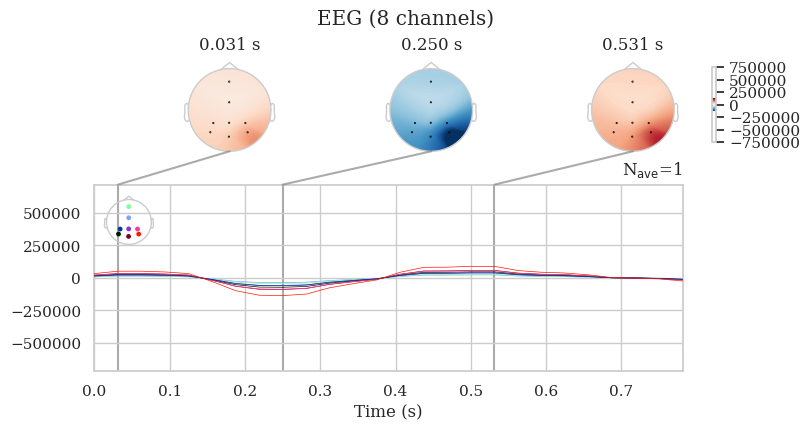

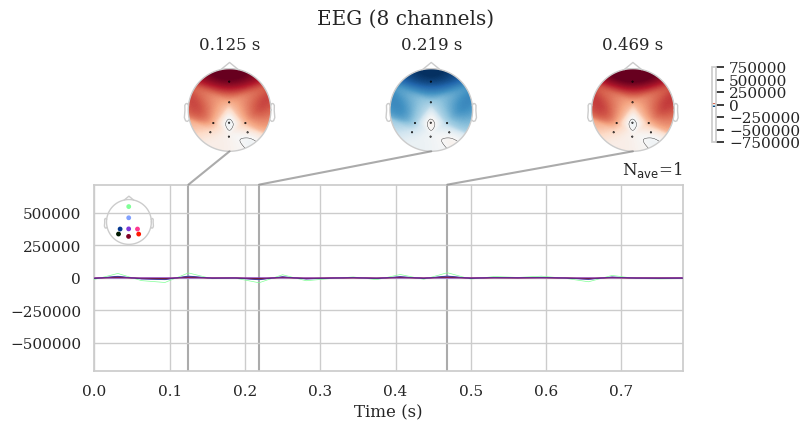

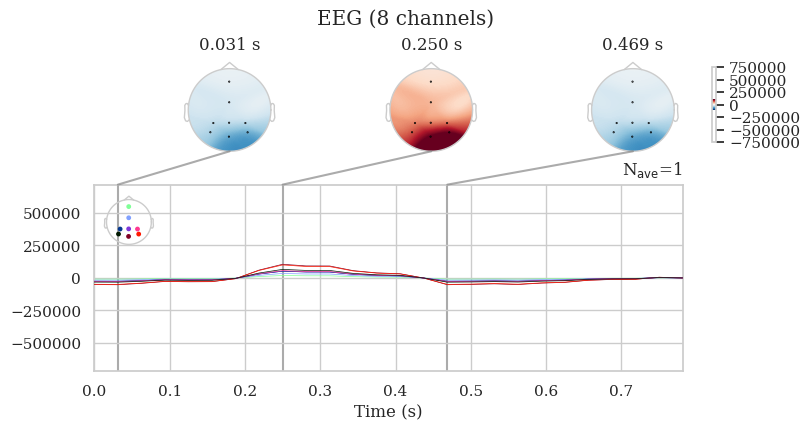

In [22]:
from mne import EvokedArray

for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)



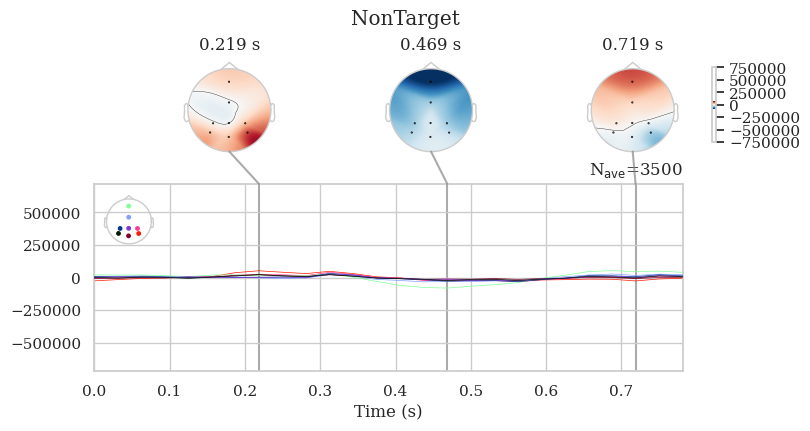

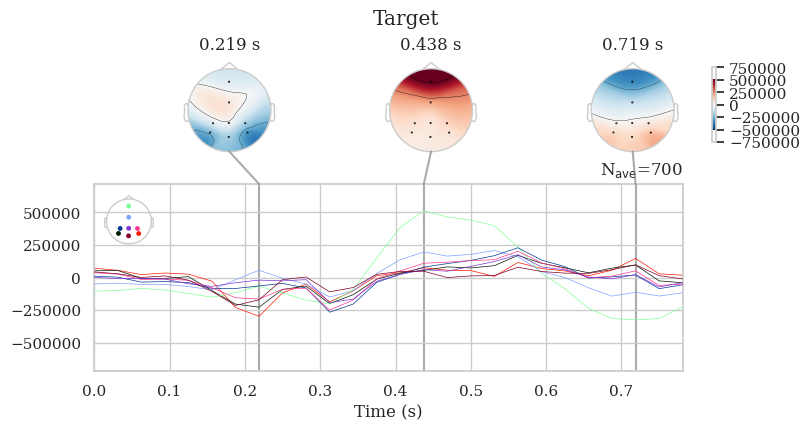

In [23]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

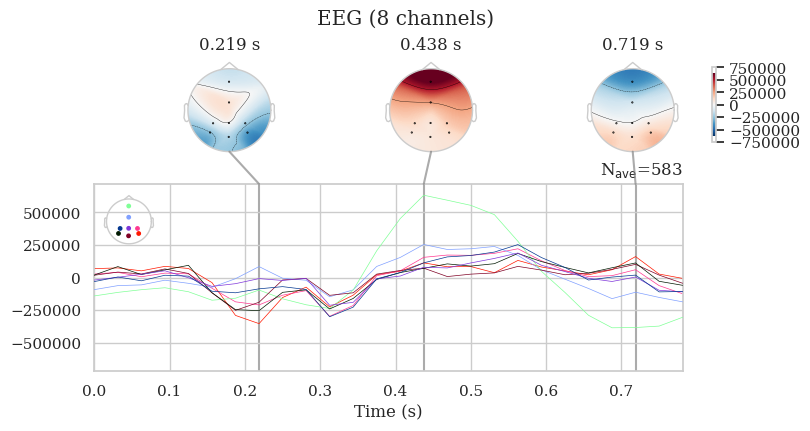

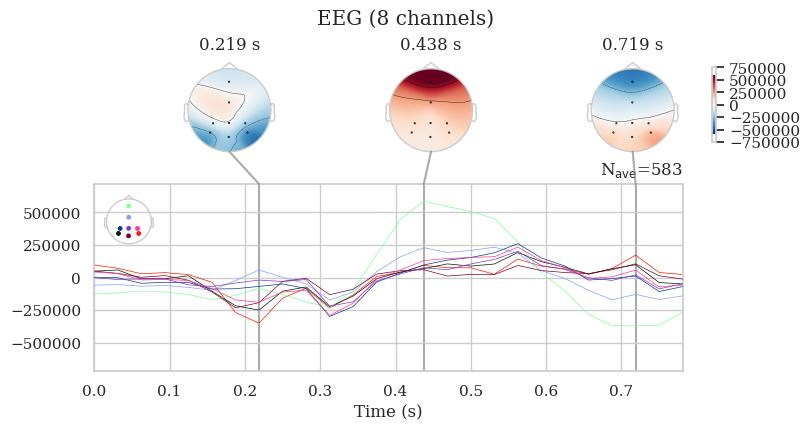

In [24]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


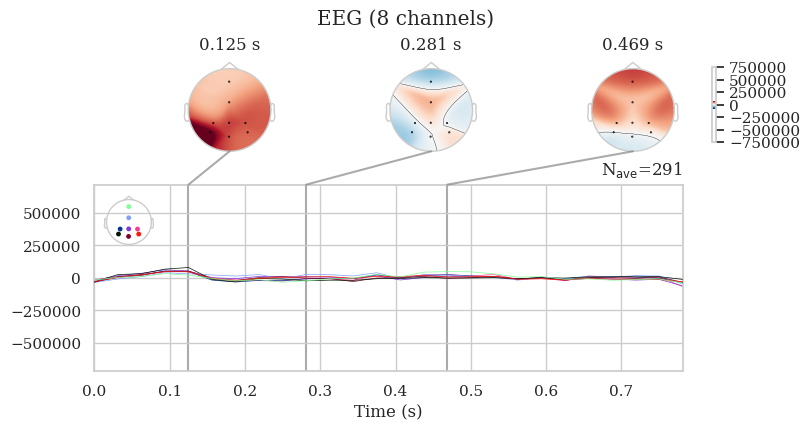

In [25]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)